In [21]:
!ls "/content/drive/MyDrive/TrashNeXt Dataset.zip"


'/content/drive/MyDrive/TrashNeXt Dataset.zip'


In [22]:
!pip install timm transformers datasets accelerate --quiet

In [23]:
import zipfile
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
zip_path="/content/drive/MyDrive/TrashNeXt Dataset.zip"
extract_path = "/content"


In [25]:
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)
!ls {extract_path}

Dataset extracted to: /content
 drive	 __MACOSX   sample_data  'TrashNeXt Dataset'


In [26]:
!ls "/content/TrashNeXt Dataset"



Test  Train  Valid


In [27]:
import os
from PIL import Image
from tqdm import tqdm

def is_corrupted_image(file_path):
    """Check if an image file is corrupted."""
    try:
        with Image.open(file_path) as img:
            img.verify()  # Verify integrity
        return False
    except (IOError, SyntaxError, Image.DecompressionBombError):
        return True

def remove_corrupted_images(dataset_path):
    """Scan and remove corrupted images + hidden macOS files."""
    corrupted_count = 0
    total_images = 0

    for root, _, files in os.walk(dataset_path):
        for file in tqdm(files, desc=f"Scanning {os.path.basename(root)}"):

            # Skip hidden files (.DS_Store, ._files)
            if file.startswith("."):
                file_path = os.path.join(root, file)
                try:
                    os.remove(file_path)
                    corrupted_count += 1
                    print(f"Removed hidden file: {file_path}")
                except:
                    pass
                continue

            # Check only image formats
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                total_images += 1
                file_path = os.path.join(root, file)
                if is_corrupted_image(file_path):
                    try:
                        os.remove(file_path)
                        corrupted_count += 1
                        print(f"Removed corrupted image: {file_path}")
                    except Exception as e:
                        print(f"Error removing {file_path}: {e}")

    print("\n✅ Scan completed!")
    print(f"📷 Total images scanned: {total_images}")
    print(f"🗑️ Corrupted/hidden files removed: {corrupted_count}")

# Run the cleaner
dataset_path = "/content/TrashNeXt Dataset"
remove_corrupted_images(dataset_path)



✅ Scan completed!
📷 Total images scanned: 0
🗑️ Corrupted/hidden files removed: 0


In [28]:
from PIL import Image
import os

def remove_truncated_images(dataset_path):
    removed_count = 0  # Counter for removed images

    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                try:
                    img = Image.open(img_path)
                    img.verify()  # Verify if the image is not corrupted
                    img.close()   # Close the image to avoid resource leaks
                except Exception as e:
                    print(f"Removing corrupted/truncated: {img_path}")
                    os.remove(img_path)
                    removed_count += 1

    print(f"\nTotal corrupted/truncated images removed: {removed_count}")

# Example usage
dataset_path = "/content/TrashNeXt Dataset"
remove_truncated_images(dataset_path)


Total corrupted/truncated images removed: 0


In [29]:
import os

dataset_path = "/content/TrashNeXt Dataset"
splits = ["Train", "Valid", "Test"]

for split in splits:
    print(f"\n{split.upper()} Split:")
    split_path = os.path.join(dataset_path, split)

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            num_images = len([f for f in os.listdir(cls_path) if not f.startswith(".")])
            print(f"  {cls}: {num_images} images")



TRAIN Split:
  cardboard: 1886 images
  e-waste: 2404 images
  foam_rubber: 2289 images
  glass: 2009 images
  medical: 1565 images
  metal: 2065 images
  organic: 2391 images
  paper: 2155 images
  plastic: 2135 images

VALID Split:
  cardboard: 236 images
  e-waste: 301 images
  foam_rubber: 287 images
  glass: 251 images
  medical: 196 images
  metal: 258 images
  organic: 299 images
  paper: 269 images
  plastic: 267 images

TEST Split:
  cardboard: 235 images
  e-waste: 301 images
  foam_rubber: 287 images
  glass: 252 images
  medical: 196 images
  metal: 258 images
  organic: 299 images
  paper: 270 images
  plastic: 267 images


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# 🔹 Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
train_dir = "/content/TrashNeXt Dataset/Train"
valid_dir = "/content/TrashNeXt Dataset/Valid"
test_dir  = "/content/TrashNeXt Dataset/Test"

# 🔹 Transforms (EfficientNetV2 standard: 300x300)
train_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

valid_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🔹 Datasets & Loaders
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=valid_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Print class names
print(f"Classes: {train_dataset.classes}")
print(f"Number of classes: {len(train_dataset.classes)}")

Using device: cuda
Classes: ['cardboard', 'e-waste', 'foam_rubber', 'glass', 'medical', 'metal', 'organic', 'paper', 'plastic']
Number of classes: 9


In [32]:
model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(train_dataset.classes))
model = model.to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✅ Model initialized for {len(train_dataset.classes)} classes on {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 152MB/s]


✅ Model initialized for 9 classes on cuda


In [33]:
# 🔹 Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [34]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
# 🔹 Training Loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100. * correct / total

    # 🔹 Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100. * val_correct / val_total
    print(f"\nEpoch [{epoch+1}/{epochs}] Train Loss: {running_loss/len(train_loader):.4f} "
          f"Train Acc: {train_acc:.2f}% Valid Acc: {val_acc:.2f}%")

Epoch 1 - Training: 100%|██████████| 591/591 [11:16<00:00,  1.15s/it]



Epoch [1/10] Train Loss: 0.0574 Train Acc: 98.19% Valid Acc: 94.96%


Epoch 2 - Training: 100%|██████████| 591/591 [11:16<00:00,  1.14s/it]



Epoch [2/10] Train Loss: 0.0506 Train Acc: 98.29% Valid Acc: 95.22%


Epoch 3 - Training: 100%|██████████| 591/591 [11:10<00:00,  1.13s/it]


...

Epoch 4 - Training: 100%|██████████| 591/591 [11:07<00:00,  1.13s/it]



Epoch [4/10] Train Loss: 0.0387 Train Acc: 98.83% Valid Acc: 94.67%


Epoch 5 - Training: 100%|██████████| 591/591 [11:11<00:00,  1.14s/it]



Epoch [5/10] Train Loss: 0.0388 Train Acc: 98.77% Valid Acc: 94.29%


Epoch 6 - Training:  63%|██████▎   | 371/591 [07:01<03:37,  1.01it/s]

In [40]:
# 🔹 Test Evaluation (EfficientNetV2)
model.eval()
test_correct, test_total = 0, 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, preds = outputs.max(1)
        test_correct += preds.eq(labels).sum().item()
        test_total += labels.size(0)

test_acc = 100. * test_correct / test_total
print(f"\nTest Loss: {test_loss/len(test_loader):.4f} | Test Accuracy: {test_acc:.2f}%")


Testing:   1%|▏         | 1/74 [00:00<00:54,  1.33it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Testing:  11%|█         | 8/74 [00:05<00:47,  1.40it/s]


KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


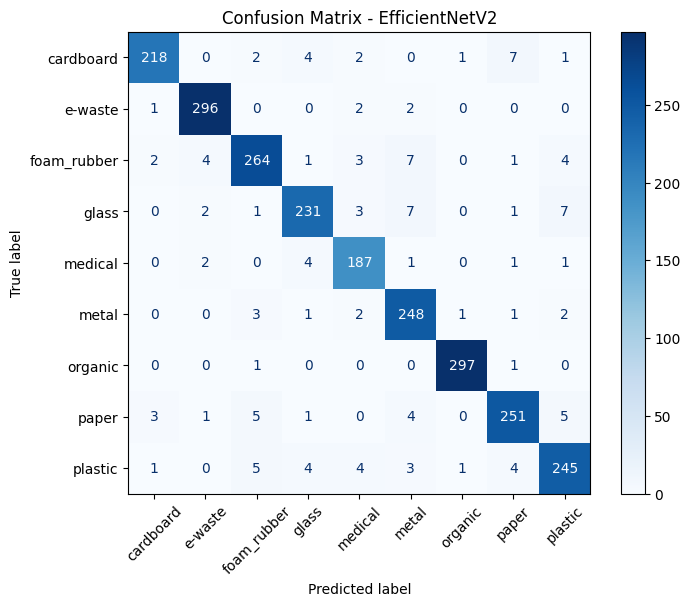

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 🔹 Collect predictions & labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🔹 Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)

# 🔹 Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - EfficientNetV2")
plt.show()


In [38]:
# 🔹 Switch to eval mode
model.eval()

# 🔹 Example input for tracing (match input size: 300x300 for EfficientNetV2)
example_input = torch.randn(1, 3, 300, 300).to(device)

# 🔹 Trace the model (strict=False allows more flexibility)
traced_model = torch.jit.trace(model, example_input, strict=False)

# 🔹 Save TorchScript
traced_model.save("efficientnetv2_trashnext_rpi.pt")

print("✅ TorchScript model saved as efficientnetv2_trashnext_rpi.pt")


✅ TorchScript model saved as efficientnetv2_trashnext_rpi.pt


In [39]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 🔹 Collect predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🔹 Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 🔹 Class-wise accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nClass-wise Accuracy:")
for cls, acc in zip(train_dataset.classes, class_accuracy):
    print(f"{cls}: {acc*100:.2f}%")

# 🔹 Full classification report (precision, recall, f1-score)
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Class-wise Accuracy:
cardboard: 92.77%
e-waste: 98.34%
foam_rubber: 92.31%
glass: 91.67%
medical: 95.41%
metal: 96.12%
organic: 99.33%
paper: 92.96%
plastic: 91.76%

Detailed Report:
              precision    recall  f1-score   support

   cardboard       0.97      0.93      0.95       235
     e-waste       0.97      0.98      0.98       301
 foam_rubber       0.94      0.92      0.93       286
       glass       0.94      0.92      0.93       252
     medical       0.92      0.95      0.94       196
       metal       0.91      0.96      0.94       258
     organic       0.99      0.99      0.99       299
       paper       0.94      0.93      0.93       270
     plastic       0.92      0.92      0.92       267

    accuracy                           0.95      2364
   macro avg       0.95      0.95      0.94      2364
weighted avg       0.95      0.95      0.95      2364

